In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import os, glob
from scipy.optimize import curve_fit
from edes.modules.detection.detection_utils import plot, plot_ax, plot_ax_errbar, plot_errbar, big_plt_font, hollow_plt_font
from resonator_tools import circuit

hollow_plt_font()

In [23]:
def plot_S11_fit(f, complex_data): 
    port1 = circuit.reflection_port()
    port1.add_data(f,complex_data)
    port1.autofit()
    fit_results = port1.fitresults
    for i in ['fr', 'Qi', 'Qc', 'Ql']: 
        if i == 'fr':
            print(f'f0 = {fit_results[i]/1e6:.3f} +- {fit_results[i+"_err"]/1e6:.3f} MHz') 
        else: 
            print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
    port1.plotall()

def plot_S21_fit(f, complex_data): 
    port1 = circuit.notch_port()
    port1.add_data(f,complex_data)
    port1.autofit()
    fit_results = port1.fitresults
    naming_map = {'Qi_no_corr': 'Qi', 'absQc': 'Qc'}
    for i in ['fr', 'Qi_no_corr', 'absQc', 'Ql']: 
        if i == 'fr':
            print(f'f0 = {fit_results[i]/1e9:.3f} +- {fit_results[i+"_err"]/1e9:.3f} GHz') 
        elif i in naming_map: 
            print(f'{naming_map[i]} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
        else: 
            print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
    port1.plotall()

def get_S21_fit(f, complex_data): 
    port1 = circuit.notch_port()
    port1.add_data(f,complex_data)
    port1.autofit()
    fit_results = port1.fitresults
    naming_map = {'Qi_no_corr': 'Qi', 'absQc': 'Qc'}
    result = {}
    for i in ['fr', 'Qi_no_corr', 'absQc', 'Ql']: 
        if i == 'fr':
            result['f0'] = (fit_results[i],fit_results[i+"_err"]) 
        elif i in naming_map: 
            result[naming_map[i]] = (fit_results[i], fit_results[i+"_err"])
        else: 
            result[i] = (fit_results[i], fit_results[i+"_err"])
    return result

In [24]:
base = r'C:\\Users\\elect\\data\\'

In [26]:
to_array = lambda x: np.array(x, dtype=np.complex128)
data_dir = base + r'warmup_02192026_trap/'
files = glob.glob('*', root_dir=data_dir) 
all_T, all_f0, all_f0_err, all_Qi, all_Qi_err, all_Qc, all_Qc_err, all_Ql, all_Ql_err = [], [], [], [], [], [], [], [], []
for csv in files:
    T = float(csv[:-4])
    file = data_dir+csv 
    df = pd.read_csv(file)
    S11, S21, freq = to_array(df['S11']), to_array(df['S21']), np.array(df['freq']) 
    res = get_S21_fit(freq, S21) 
    f0, f0_err = res['f0'] 
    Qi, Qi_err = res['Qi'] 
    Qc, Qc_err = res['Qc'] 
    Ql, Ql_err = res['Ql']
    all_T.append(T) 
    all_f0.append(f0) 
    all_f0_err.append(f0_err) 
    all_Qi.append(Qi) 
    all_Qi_err.append(Qi_err) 
    all_Qc.append(Qc) 
    all_Qc_err.append(Qc_err) 
    all_Ql.append(Ql) 
    all_Ql_err.append(Ql_err) 
all_T = np.array(all_T)
all_f0 = np.array(all_f0)
all_f0_err = np.array(all_f0_err)
all_Qi = np.array(all_Qi)
all_Qi_err = np.array(all_Qi_err)
all_Qc = np.array(all_Qc)
all_Qc_err = np.array(all_Qc_err)
all_Ql = np.array(all_Ql)
all_Ql_err = np.array(all_Ql_err)

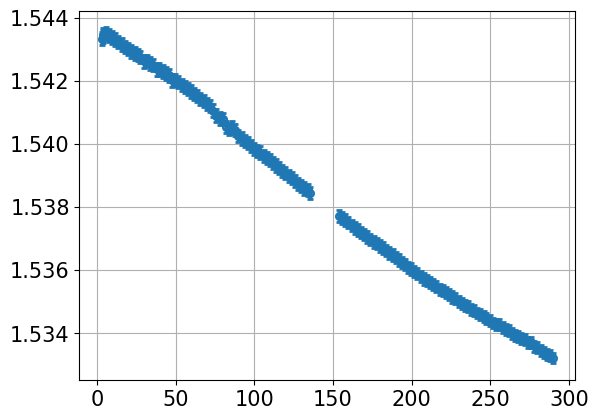

In [60]:

plot_errbar(all_T, all_f0/1e9, all_f0_err/1e9, fmt='.')

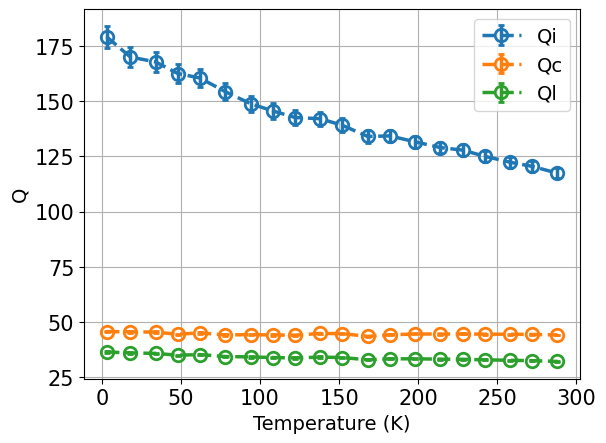

In [28]:
num_points = 20 

# 2. Create an equally spaced grid across your temperature range
t_min, t_max = all_T.min(), all_T.max()
ideal_grid = np.linspace(t_min, t_max, num_points)

# 3. Find the index of the real data point closest to each grid value
indices = []
for val in ideal_grid:
    # Calculate absolute difference and find the minimum index
    idx = (np.abs(all_T - val)).argmin()
    if idx not in indices: # Avoid duplicates if data is very sparse
        indices.append(idx)

# 4. Create your sub-sampled arrays
spaced_T = all_T[indices]
spaced_Qi = all_Qi[indices]
spaced_Qi_err = all_Qi_err[indices]
spaced_Qc = all_Qc[indices] 
spaced_Qc_err = all_Qc_err[indices] 
spaced_Ql = all_Ql[indices] 
spaced_Ql_err = all_Ql_err[indices]
plot_errbar(spaced_T, spaced_Qi, spaced_Qi_err, fmt='o--', label='Qi') 
#plot_errbar(all_Tw, all_Qiw, all_Qi_errw, fmt='x', label='Qi', alpha=0.5) 
plot_errbar(spaced_T, spaced_Qc, spaced_Qc_err, fmt='o--', label='Qc') 
plot_errbar(spaced_T, spaced_Ql, spaced_Ql_err, fmt='o--', label='Ql', xlabel='Temperature (K)', ylabel='Q') 
plt.legend() 
# plt.yscale('log')
plt.show()

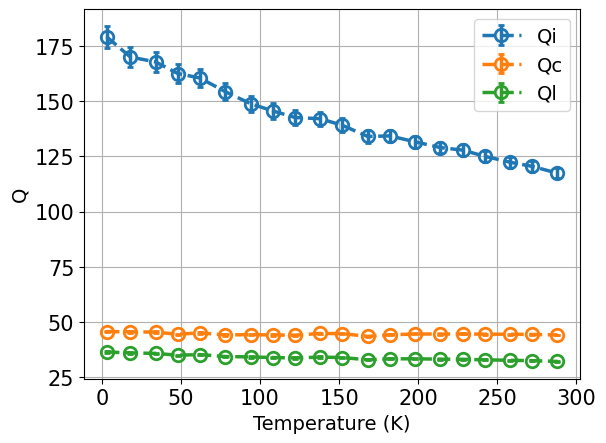

In [29]:
num_points = 20 

# 2. Create an equally spaced grid across your temperature range
t_min, t_max = all_T.min(), all_T.max()
ideal_grid = np.linspace(t_min, t_max, num_points)

# 3. Find the index of the real data point closest to each grid value
indices = []
for val in ideal_grid:
    # Calculate absolute difference and find the minimum index
    idx = (np.abs(all_T - val)).argmin()
    if idx not in indices: # Avoid duplicates if data is very sparse
        indices.append(idx)

# 4. Create your sub-sampled arrays
spaced_T = all_T[indices]
spaced_Qi = all_Qi[indices]
spaced_Qi_err = all_Qi_err[indices]
spaced_Qc = all_Qc[indices] 
spaced_Qc_err = all_Qc_err[indices] 
spaced_Ql = all_Ql[indices] 
spaced_Ql_err = all_Ql_err[indices]
plot_errbar(spaced_T, spaced_Qi, spaced_Qi_err, fmt='o--', label='Qi') 
# plot_errbar(all_Tw, all_Qiw, all_Qi_errw, fmt='x', label='Qi', alpha=0.5) 
plot_errbar(spaced_T, spaced_Qc, spaced_Qc_err, fmt='o--', label='Qc') 
plot_errbar(spaced_T, spaced_Ql, spaced_Ql_err, fmt='o--', label='Ql', xlabel='Temperature (K)', ylabel='Q') 
plt.legend() 
# plt.yscale('log')
# plt.xlim(60,90)
# plt.ylim(150,170)
plt.show()

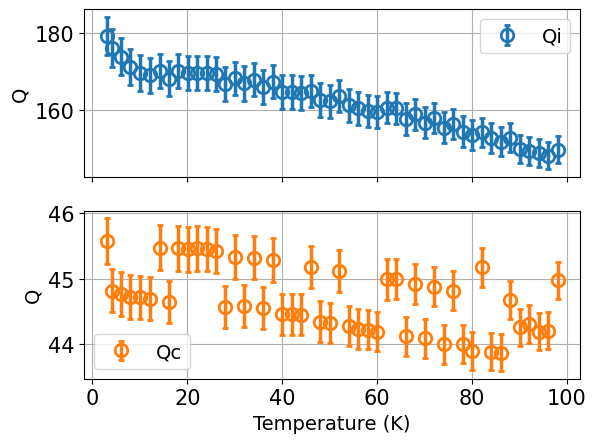

In [33]:
low_T_idx = np.where(all_T< 100) 
low_T = all_T[low_T_idx] 
low_T_Qi = all_Qi[low_T_idx] 
low_T_Qi_err = all_Qi_err[low_T_idx] 
low_T_Qc = all_Qc[low_T_idx] 
low_T_Qc_err = all_Qc_err[low_T_idx] 
fig, ax = plt.subplots(nrows=2, sharex=True)
plot_ax_errbar(ax[0], low_T, low_T_Qi, low_T_Qi_err, fmt='o', label='Qi', ylabel='Q') 
plot_ax_errbar(ax[1], low_T, low_T_Qc, low_T_Qc_err, fmt='o', color='C1', label='Qc', xlabel='Temperature (K)', ylabel='Q') 
# plt.yscale('log') 
ax[0].legend()
ax[1].legend()
plt.show()

In [70]:
all_Tw, all_Qiw, all_Qi_errw = all_T, all_Qi, all_Qi_err

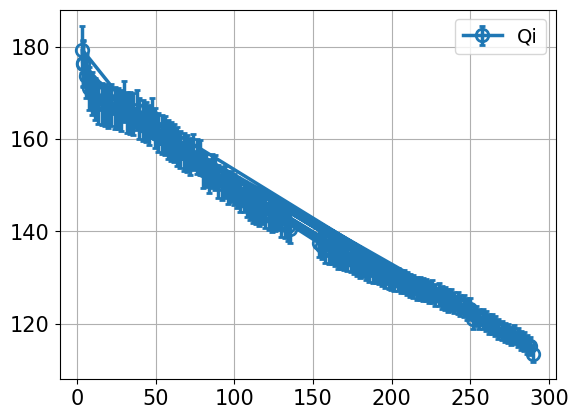

In [66]:
plot_errbar(all_T, all_Qi, all_Qi_err, fmt='o-', label='Qi') 
plt.legend() 

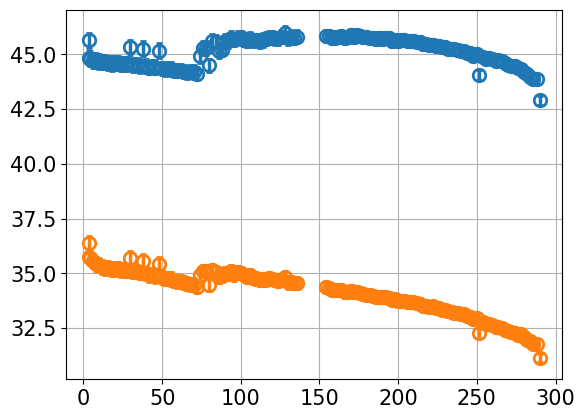

In [65]:
plot_errbar(all_T, all_Qc, all_Qc_err, fmt='o', label='Qc') 
plot_errbar(all_T, all_Ql, all_Ql_err, fmt='o', label='Ql')